Method             n   Final mean    Final std   Unstable mean  Unstable std
--------------------------------------------------------------------------------
C-UI-TVBO          9        1.478        0.301            0.00          0.00
UI-TVBO            5        2.127        0.462            2.00          0.63
C-TV-GP-UCB        5        2.073        0.312            0.00          0.00
TV-GP-UCB          5        2.870        1.457           10.80          1.60


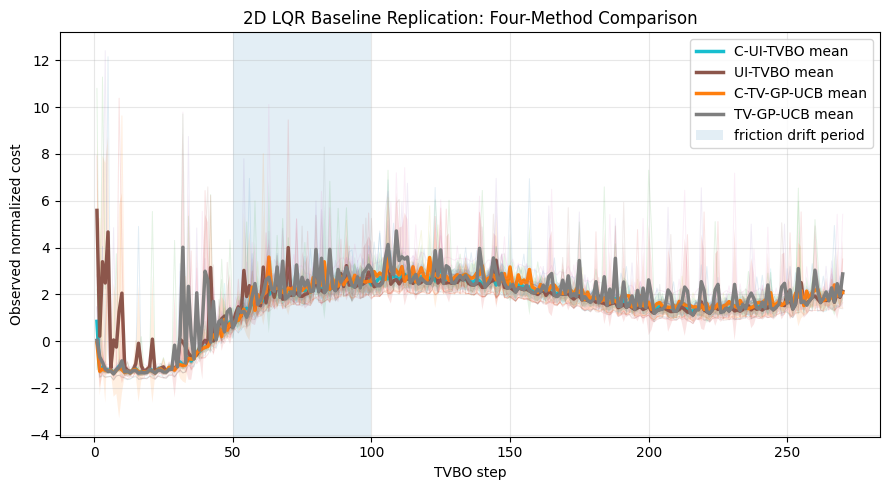

In [1]:
import os, glob, pickle
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = "results/baseline"   
methods = {
    "C-UI-TVBO": "results_UI_2DLQR_constrained_forgetting_factor_0_03_baseline_0_03_*.pickle",
    "UI-TVBO": "results_UI_2DLQR_unconstrained_forgetting_factor_0_03_baseline_0_03_*.pickle",
    "C-TV-GP-UCB": "results_B2P_OU_2DLQR_constrained_forgetting_factor_0_03_baseline_0_03_*.pickle",
    "TV-GP-UCB": "results_B2P_OU_2DLQR_unconstrained_forgetting_factor_0_03_baseline_0_03_*.pickle",
}

def load_pickles(pattern):
    files = sorted(glob.glob(os.path.join(BASE_DIR, pattern)))
    out = []
    for f in files:
        with open(f, "rb") as fh:
            out.append(pickle.load(fh))
    return out

def get_curve(data, n_initial=30):
    f = np.asarray(data["f_of_x"]).reshape(-1)
    return f[n_initial:]

def count_unstable(data, n_initial=30):
    return sum(1 for s in data["stable"][n_initial:] if not s)

plt.figure(figsize=(9, 5))

print(f"{'Method':<15} {'n':>4} {'Final mean':>12} {'Final std':>12} {'Unstable mean':>15} {'Unstable std':>13}")
print("-" * 80)

for label, pattern in methods.items():
    trials = load_pickles(pattern)
    if not trials:
        print(label, "NO FILES FOUND")
        continue

    curves = [get_curve(d, n_initial=30) for d in trials]
    min_len = min(len(c) for c in curves)
    curves = np.array([c[:min_len] for c in curves])

    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)
    t = np.arange(1, min_len + 1)

    for c in curves:
        plt.plot(t, c, alpha=0.12, linewidth=0.7)

    plt.plot(t, mean_curve, linewidth=2.5, label=f"{label} mean")
    plt.fill_between(t, mean_curve - std_curve, mean_curve + std_curve, alpha=0.12)

    unstable = [count_unstable(d, n_initial=30) for d in trials]

    print(f"{label:<15} {len(trials):>4} {mean_curve[-1]:>12.3f} {std_curve[-1]:>12.3f} "
          f"{np.mean(unstable):>15.2f} {np.std(unstable):>13.2f}")

plt.axvspan(50, 100, alpha=0.12, label="friction drift period")
plt.xlabel("TVBO step")
plt.ylabel("Observed normalized cost")
plt.title("2D LQR Baseline Replication: Four-Method Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("results/baseline_4methods_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

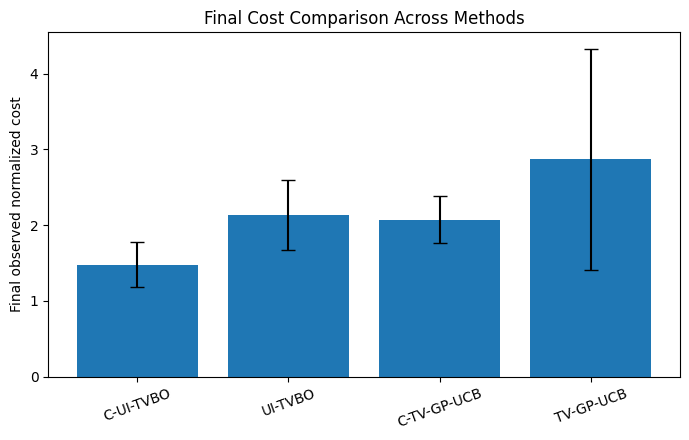

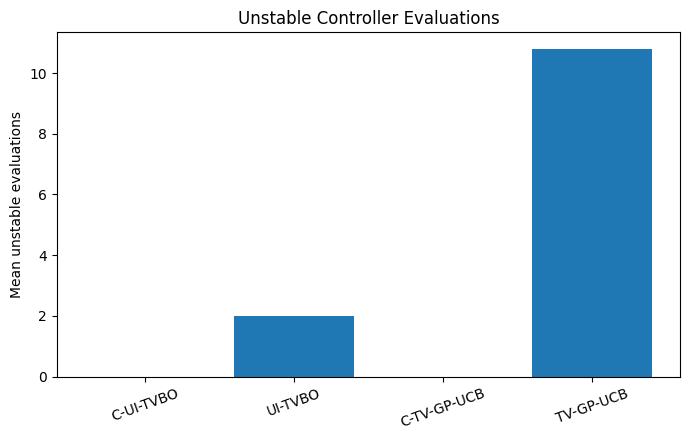

In [2]:
import matplotlib.pyplot as plt
import numpy as np

methods = ["C-UI-TVBO", "UI-TVBO", "C-TV-GP-UCB", "TV-GP-UCB"]
final_mean = [1.478, 2.127, 2.073, 2.870]
final_std = [0.301, 0.462, 0.312, 1.457]
unstable_mean = [0.00, 2.00, 0.00, 10.80]

x = np.arange(len(methods))

plt.figure(figsize=(7, 4.5))
plt.bar(x, final_mean, yerr=final_std, capsize=5)
plt.xticks(x, methods, rotation=20)
plt.ylabel("Final observed normalized cost")
plt.title("Final Cost Comparison Across Methods")
plt.tight_layout()
plt.savefig("results/baseline_final_cost_bar.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4.5))
plt.bar(x, unstable_mean)
plt.xticks(x, methods, rotation=20)
plt.ylabel("Mean unstable evaluations")
plt.title("Unstable Controller Evaluations")
plt.tight_layout()
plt.savefig("results/baseline_unstable_bar.png", dpi=300, bbox_inches="tight")
plt.show()